# Mario RL: Environment and Observation Setup

This notebook follows the PyTorch Mario RL tutorial using a modern Gymnasium-compatible stack. These first cells create the game environment, inspect one agent decision, and begin preprocessing its observations.

## 1. Import the environment tools

This cell imports Gymnasium, the Super Mario Bros environment, and `JoypadSpace`, which converts simple numbered actions into NES button presses. `pprint` formats the environment's extra diagnostic information so it is easier to read.

In [4]:
# Gymnasium API (modernized stack: gymnasium + gym-super-mario-bros>=9.1)
from pprint import pprint

import gym_super_mario_bros
import gymnasium as gym
from nes_py.wrappers import JoypadSpace

## 2. Create and inspect one environment step

This cell creates Mario level 1-1 and restricts the agent to two actions: move right, or move right while jumping. It resets the game, takes action `0`, and prints the resulting image shape, reward, episode-ending flags, and diagnostic `info` dictionary. This verifies the raw observation-and-feedback loop before preprocessing.

In [5]:
env = gym_super_mario_bros.make(
    "SuperMarioBros-1-1-v0",
    render_mode="rgb_array",
)

env = JoypadSpace(env, [["right"], ["right", "A"]])

obs, info = env.reset()
next_obs, reward, terminated, truncated, info = env.step(0)

episode_done = terminated or truncated

print("next observation:", next_obs.shape)
print("reward:", reward)
print("terminated:", terminated)
print("truncated:", truncated)
pprint(info)

next observation: (240, 256, 3)
reward: 0.0
terminated: False
truncated: False
{'area': 1,
 'clear': False,
 'coins': 0,
 'death': False,
 'enemy_types': (0, 0, 0, 0, 0),
 'flag_get': False,
 'game': 'smb1',
 'game_family': 'smb1',
 'is_dead': False,
 'is_dying': False,
 'is_game_over': False,
 'is_stage_over': False,
 'is_world_over': False,
 'left_x_pos': 40,
 'level': 0,
 'life': 2,
 'lives': 2,
 'player_state': 8,
 'powerup_level': 0,
 'progress': 40,
 'progress_max': 40,
 'reward_components': {'coins': 0.0,
                       'completion': 0.0,
                       'death': 0.0,
                       'powerup': 0.0,
                       'progress': 0.0,
                       'score': 0.0,
                       'time': 0.0},
 'reward_total_clipped': 0.0,
 'reward_total_unclipped': 0.0,
 'rom_mode': 'vanilla',
 'score': 0,
 'single_stage': True,
 'stage': 1,
 'status': 'small',
 'status_value': 0,
 'target_stage': 1,
 'target_world': 1,
 'task_id': 'SuperMarioBros-1-1-v0'

## 3. Define `SkipFrame`

`SkipFrame` is a Gymnasium wrapper that repeats one selected action for several game frames. It adds the rewards earned across those frames, returns the final observation, and stops early when the episode ends. The positive `skip` check prevents a zero-iteration loop with no observation to return.

In [7]:
class SkipFrame(gym.Wrapper):
    """Repeat one action for several frames and sum its rewards."""

    def __init__(self, env: gym.Env, skip: int) -> None:
        super().__init__(env)
        if skip < 1:
            raise ValueError("skip must be at least 1")
        self._skip = skip


    def step(self, action: int) -> tuple:
        total_reward = 0.0

        for _ in range(self._skip):
            obs, reward, terminated, truncated, info = self.env.step(action)
            total_reward += reward

            if terminated or truncated:
                break

        return obs, total_reward, terminated, truncated, info

## 4. Test `SkipFrame`

This cell wraps the existing Mario environment with `skip=4`, resets it, and takes one rightward action. The image shape should remain `(240, 256, 3)` because this wrapper changes decision frequency, not image size; the printed reward represents up to four game frames.

In [8]:
wrapped_env = SkipFrame(env, skip=4)

obs, info = wrapped_env.reset()
next_obs, reward, terminated, truncated, info = wrapped_env.step(0)

print("shape:", next_obs.shape)
print("four-frame reward:", reward)
print("episode ended:", terminated or truncated)

shape: (240, 256, 3)
four-frame reward: 0.0
episode ended: False


## 5. Visualize the raw observation

This cell displays the RGB image currently returned to the agent after frame skipping. It is a human-facing check of the same
pixel data that later preprocessing wrappers will transform.

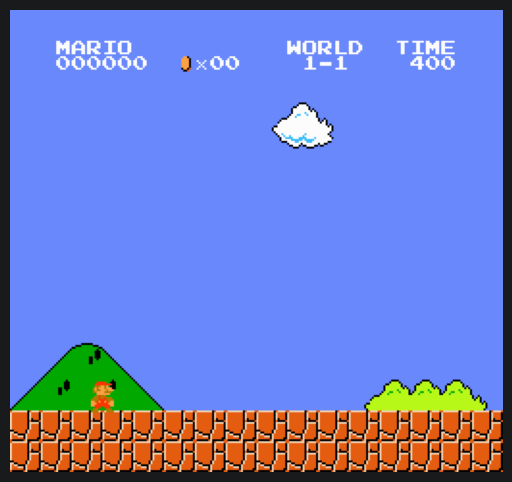

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(next_obs)
plt.axis("off")
plt.show()

## 6. Convert observations to grayscale

This cell removes RGB color channels while preserving Mario’s visible shapes. The result is one brightness value per pixel,
 which reduces the observation from three dimensions to two.

In [10]:
from gymnasium.wrappers import GrayscaleObservation

gray_env = GrayscaleObservation(wrapped_env, keep_dim=False)

gray_obs, info = gray_env.reset()
gray_next_obs, reward, terminated, truncated, info = gray_env.step(0)
print("grayscale shape:", gray_next_obs.shape)
print("dtype:", gray_next_obs.dtype)
print("reward:", reward)

grayscale shape: (240, 256)
dtype: uint8
reward: 0.0


## 7. Resize observations

This cell shrinks each grayscale Mario frame from `(240, 256)` to `(84, 84)`. It also converts brightness values from integers
 between 0 and 255 into decimal values between 0.0 and 1.0.

In [11]:
import numpy as np
import torch
from torchvision import transforms as T


class ResizeObservation(gym.ObservationWrapper):
    """Resize a grayscale observation to a normalized square image.

    An ObservationWrapper changes images returned by an environment, not its actions or rewards.
    """

    def __init__(self, env: gym.Env, shape: int | tuple[int, int]) -> None:
        super().__init__(env)

        self.shape: tuple[int, int] = (
            (shape, shape) if isinstance(shape, int) else shape
        )
        # Prepare a smoother transform that downsamples every incoming image.
        self._resize = T.Resize(self.shape, antialias=True)
        # Describe output pixels: normalized float32 brightness values in the new shape.
        self.observation_space = gym.spaces.Box(
            low=0.0,  # Black.
            high=1.0,  # White.
            shape=self.shape,  # The resized height and width.
            dtype=np.float32,  # Fractional pixel values.
        )

    # Gymnasium calls this method whenever the wrapped environment returns an observation.
    def observation(self, observation: np.ndarray) -> np.ndarray:
        # The grayscale input starts as (height, width). `unsqueeze(0)` adds a
        # first axis of size one, producing (1, height, width) without adding pixels.
        image = torch.as_tensor(observation, dtype=torch.float32).unsqueeze(0)
        # Resize produces (1, 84, 84). `squeeze(0)` removes that first size-one
        # channel axis, returning (84, 84), then division scales brightness to 0.0-1.0.
        resized = self._resize(image).squeeze(0) / 255.0
        # Return a NumPy array because Gymnasium environments use NumPy observations.
        return resized.numpy()


In [12]:
resized_env = ResizeObservation(gray_env, shape=84)

resized_obs, info = resized_env.reset()
resized_next_obs, reward, terminated, truncated, info = resized_env.step(0)

print("resized shape:", resized_next_obs.shape)
print("dtype:", resized_next_obs.dtype)
print("min/max:", resized_next_obs.min(), resized_next_obs.max())

resized shape: (84, 84)
dtype: float32
min/max: 0.15468283 0.9882354


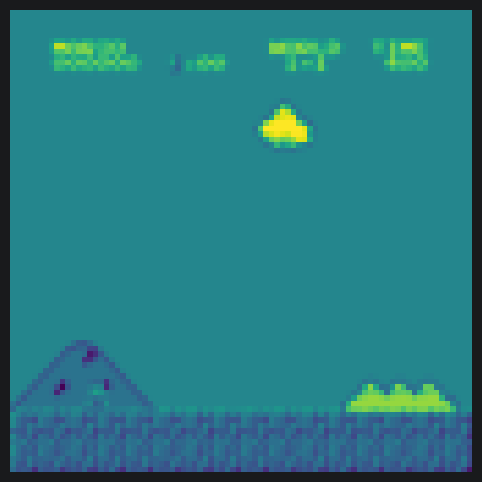

In [13]:
plt.figure(figsize=(8, 6))
plt.imshow(resized_next_obs)
plt.axis("off")
plt.show()